# 04 - Plotting: Trim, Multiplot, And Multimultiplot

This notebook focuses only on plotting mechanics. You will trim CVs for focused views, build polished `multiplot()` overlays, use legends and scale bars, encode ordered series with gradients and colorbars, and compare grouped data with `multimultiplot()`.

Use notebook 02 for the everyday load/filter/group workflow. Come here when the question is “how should this figure look?”

## Import eCAT And Set Paths

This uses the shorter setup pattern introduced after notebook 02. The same packaged Fe/PhOH CV data are used so the examples run end-to-end.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent


def display_path(path):
    path = Path(path)
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        return path.name

if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ecat as e

DATA_DIR = ROOT / "examples" / "data" / "fe_phoh_cv"
EXPORT_DIR = ROOT / "notebooks" / "_outputs"
EXPORT_DIR.mkdir(exist_ok=True)

print("eCAT version:", getattr(e, "__version__", "unknown"))
print("Example data:", display_path(DATA_DIR))
print("Text files:", len(list(DATA_DIR.glob("*.txt"))))

eCAT version: 0.1.0b2
Example data: examples/data/fe_phoh_cv
Text files: 13


## Set Plotting Style And Session Defaults

This notebook is a good place to experiment with plotting style because every later cell makes a figure. `plotting_style()` changes Matplotlib rcParams for the current Python session, while `set_defaults()` changes eCAT option defaults for the rest of the notebook.

Available style profiles are `"notebook"`, `"publication"`, and `"saveant"`; use `False`, `"default"`, or `"matplotlib"` to restore Matplotlib defaults. The Savéant-inspired style uses a blue-tinted plotting area, compact inside-axis symbol labels (`E`, `i`, `j`, `t`, and `Q`), denser outward ticks on the bottom and left axes, and axis limits snapped outward to the next major ticks.

Try changing the style, figure size, minor-tick density, symbol-label setting, legend setting, or units below, then rerun the entire notebook from the top. That is the easiest way to see how a notebook-wide default affects a full plotting workflow. Local options passed directly into `.plot()` or `multiplot()` still win for that one figure.

In [2]:
# Try "notebook", "publication", or "saveant".
# Use False, "default", or "matplotlib" to restore Matplotlib defaults.
e.plotting_style("notebook")

_ = e.set_defaults("plot", {
    "figure.figsize": [5.0, 3.75],
    "minor ticks": 4,
})

_ = e.set_defaults("multiplot", {
    "legend": True,
    "legend outside": False,
    "x unit": "V",
    "y unit": "uA",
    "plot convention": "US",
})

## Load And Select Plotting Examples

Keep `reference mode` set to `"none"` here so this notebook stays focused on plotting rather than reference correction. The import options include the electrode area in cm², which lets any later plot request current density directly without re-entering area for every CV.

This notebook also introduces `name alterations`: these are filename text replacements applied during import, before eCAT builds names, compounds, and labels. Here `Fe-tpyPY2Me` is shortened to `[Fe]`, so filters and plot labels can use the cleaner lab shorthand.

The cells below create three useful subsets: the full CO2 series, a PhOH titration under CO2, and an Ar scan-rate series.


In [3]:
all_cvs = e.get_data({
    "folder path": str(DATA_DIR),
    "reference mode": "none",
    "electrode area": 0.071,
    "print": False,
    "invert current": True,
    "name alterations": {"Fe-tpyPY2Me": "[Fe]"},
})
cvs = e.filter(all_cvs, {"segments": 3}, {"print": False})
multiscan_cv = e.filter(all_cvs, {"segments": 9}, {"print": False})[0]

co2 = e.filter(cvs, {"gas": "CO2"}, {"print": False})
phoh_co2 = e.filter(cvs, {
    "gas": "CO2",
    "compounds": "PhOH",
}, {"logic": "AND", "print": False})

fe_ar = e.filter(cvs, {
    "gas": "Ar",
    "compounds": "[Fe]",
}, {"logic": "AND", "print": False})
scan_series = e.filter(fe_ar, {
    "scan window": [-1.7, 1],
}, {"print": False})
scan_series = e.sort(scan_series, "scan rate", {"print": False})


e.show_objects(scan_series, {
    "columns": ["gas", "scan rate", "compounds", "scan window", "electrode area"],
});


Searching recursively through:
 examples/data/fe_phoh_cv
13 .txt files found.

[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.7, 1], Segments: 3, IR Comp Percent: 100 %


,Gas,Compounds,Scan Window,Scan Rate,Electrode Area
[0],Ar,,"[-1.7, 1]",25 mV/s,0.071
[1],Ar,,"[-1.7, 1]",50 mV/s,0.071
[2],Ar,,"[-1.7, 1]",100 mV/s,0.071
[3],Ar,,"[-1.7, 1]",500 mV/s,0.071
[4],Ar,,"[-1.7, 1]",1 V/s,0.071


## Trim A CV Before Plotting

`trim()` returns a CV copy with a smaller potential window. This is useful when you want a focused view without changing the original object. By default, eCAT expands disconnected pointwise windows enough to preserve a connected CV waveform; use `mode: "pointwise"` only when you intentionally want pointwise trimming.

The cell below trims one CO2 trace to the feature-rich region and plots the trimmed copy. The original object is still unchanged.

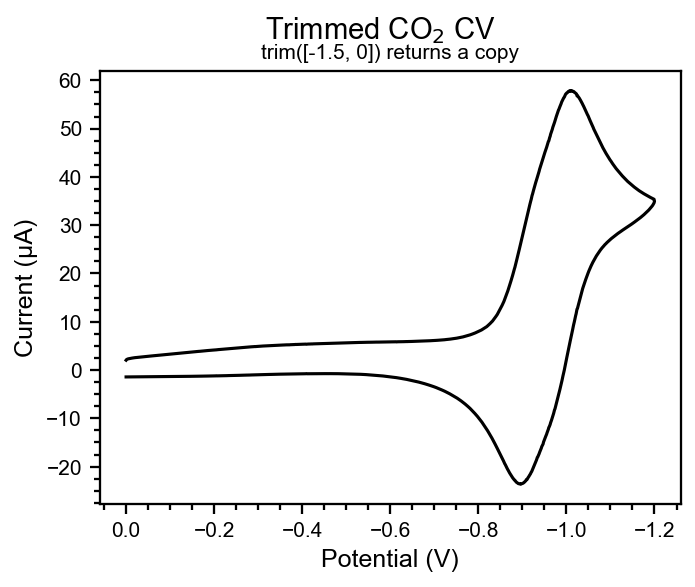

In [4]:
trimmed_cv = co2[0].trim([-1.5, 0])

ax = trimmed_cv.plot({
    "print": False,
    "title": "Trimmed CO$_2$ CV",
    "subtitle": "trim([-1.5, 0]) returns a copy",
})

## Plot A Multiscan Export

A multiscan CH export imports as one CV object with multiple connected segments, not as a list of separate CVs. For that case, use the normal `.plot()` method and choose segments with `plot segments`.

The example below uses a clean `[Fe]`-only Ar multiscan. `segment color mode: "discrete gradient"` colors each selected segment separately and `legend mode: "colorbar"` keeps the segment labels compact. Try changing `plot segments` to `[1, 2]`, `[7, 8, 9]`, or removing it entirely to see how the full multiscan is handled.


Multiscan segments: 9


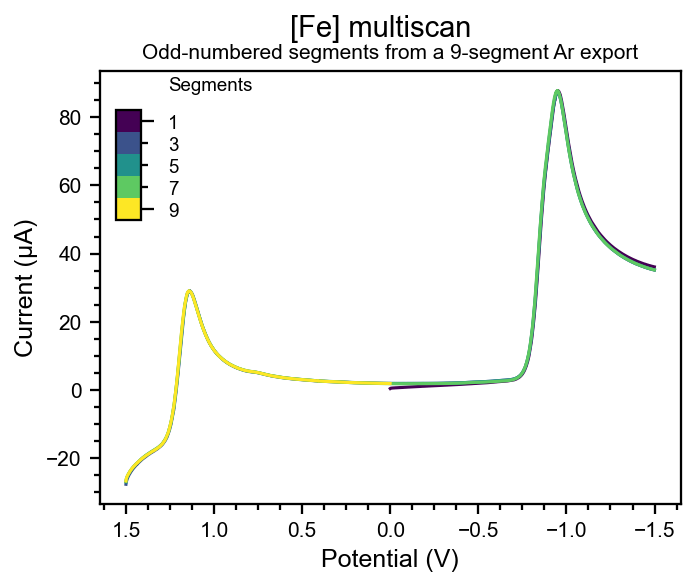

In [5]:
print("Multiscan segments:", multiscan_cv.segments)

ax = multiscan_cv.plot({
    "print": False,
    "title": "[Fe] multiscan",
    "subtitle": "Odd-numbered segments from a 9-segment Ar export",
    "plot segments": [1, 3, 5, 7, 9],
    "segment color mode": "discrete gradient",
    "segment color groups": 1,
    "colorbar height": 2,
    "legend": True,
    "legend mode": "colorbar",
    "colorbar tick labels": "all",
})


## Customize Overlay Labels, Titles, And Legends

Start with the information architecture of the figure: title, subtitle, trace labels, and legend placement. `plot labels` replaces automatic labels in order, `legend loc` chooses where the legend anchors, and `legend outside` moves it out of the axes when the traces need more plotting area.

Axis units and axis choices are passed through `multiplot()`. Because the CVs were imported with an electrode area, `y axis: "current density"` converts the current response to current density at plot time. Axis limits are ordinary Matplotlib settings on the returned `ax`, so use `ax.set_xlim(...)` and `ax.set_ylim(...)` after the plot call.

(-3000.0, 3000.0)

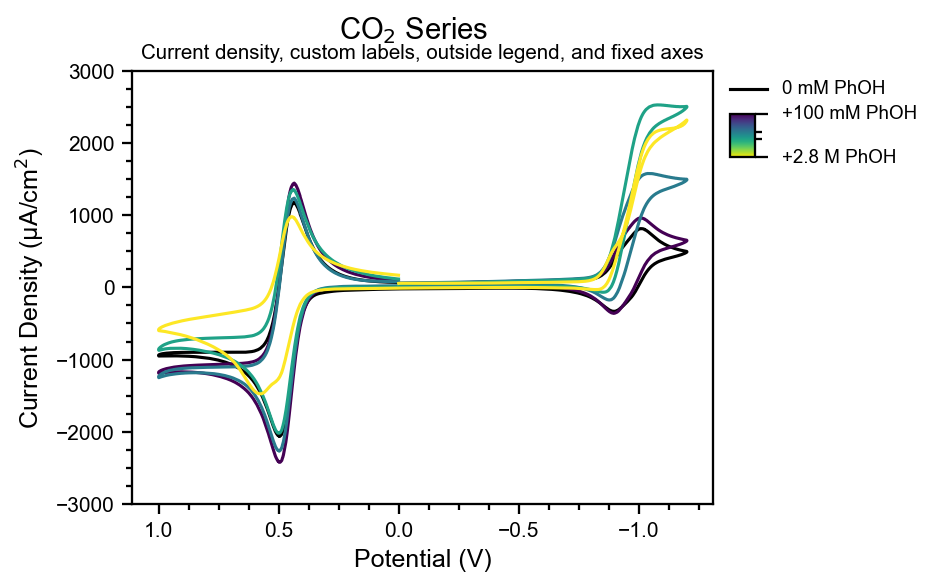

In [6]:
ax = e.multiplot(co2, {
    "print": False,
    "title": "CO$_2$ Series",
    "subtitle": "Current density, custom labels, outside legend, and fixed axes",
    "plot labels": [
        "0 mM PhOH",
        "100 mM PhOH",
        "560 mM PhOH",
        "1 M PhOH",
        "2.8 M PhOH",
    ],
    "legend": True,
    "legend loc": "upper right",
    "legend outside": True,
    "x unit": "V",
    "y axis": "current density",
    "plot convention": "US",
})

ax.set_ylim(-3000, 3000)

## Add A Scale Bar

A scale bar is helpful when the exact y-axis tick labels are less important than the relative size of the current response. The `scale bar` option can be `True`, a numeric length, or a small dictionary. In dictionary form, `length` is in the displayed y-axis units, `loc` places the bar, and `label pad` adjusts label spacing.

Use this sparingly: scale bars are most useful for compact overlays or publication-style figures where visual comparison matters more than reading exact axis ticks.

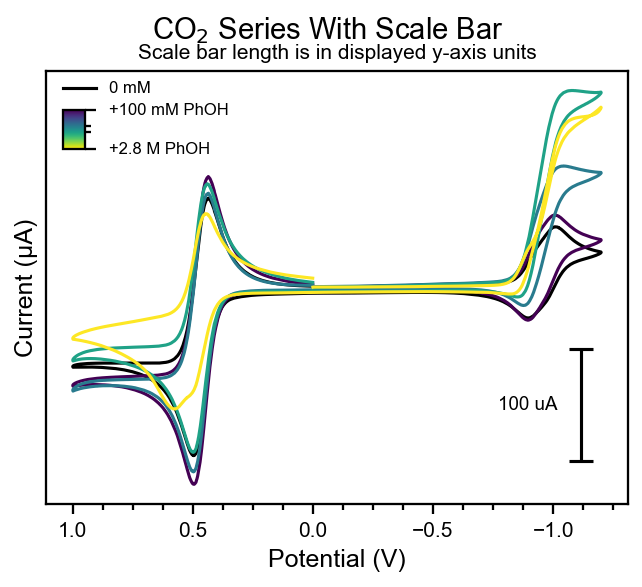

In [7]:
ax = e.multiplot(co2, {
    "print": False,
    "title": "CO$_2$ Series With Scale Bar",
    "subtitle": "Scale bar length is in displayed y-axis units",
    "plot labels": ["0 mM", "100 mM", "560 mM", "1 M", "2.8 M"],
    "legend": True,
    "legend loc": "upper left",
    "legend fontsize": 8,
    "scale bar": {"loc": "lower right", "length": 100, "label pad": .05},
})

## Use Gradients And Colorbar Legends

For ordered series, a color gradient is often easier to read than a long discrete legend. `gradient by` tells eCAT which metadata field should control color. Common choices are `"scan rate"` and `"concentration"`; `"auto"` lets eCAT infer a sensible gradient when the list has enough ordered metadata.

`legend mode: "colorbar"` turns the gradient into a compact colorbar legend. Use `colorbar tick labels: "all"` when every trace should be labeled, `"endpoints"` for a cleaner minimum/maximum legend, or `"none"` when the colorbar is only contextual. `colorbar trace ticks` controls whether each trace value gets a tick mark even when not every tick has text.

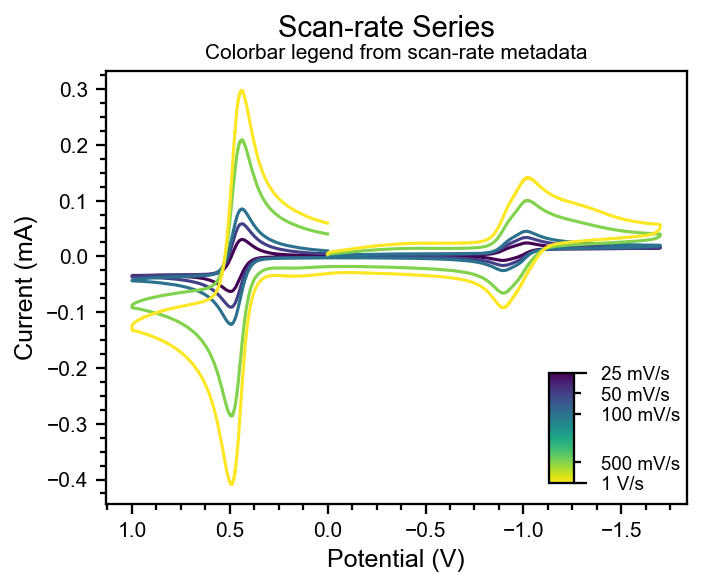

In [8]:
ax = e.multiplot(scan_series, {
    "print": False,
    "title": "Scan-rate Series",
    "subtitle": "Colorbar legend from scan-rate metadata",
    "gradient by": "scan rate",
    "legend mode": "colorbar",
    "colorbar height": 2.0,
    "colorbar tick labels": "all",
    "colorbar trace ticks": True,
    "y unit": "mA",
})

## Choose Colormaps And Gradient Direction

Use `gradient colormap` to choose a Matplotlib colormap by name, such as `"viridis"`, `"plasma"`, `"rainbow"`, or `"magma"`. `gradient reverse` flips the color direction when the natural visual order feels backward. `gradient scale` controls how values are mapped into the colormap: `"linear"`, `"sqrt"`, `"log"`, or `"index"`.

For unevenly spaced scan rates or concentrations, `"index"` often gives the most visually separated traces because each trace gets equal color spacing. For quantitative colorbars, prefer `"linear"`, `"sqrt"`, or `"log"` when those scales match the experiment.

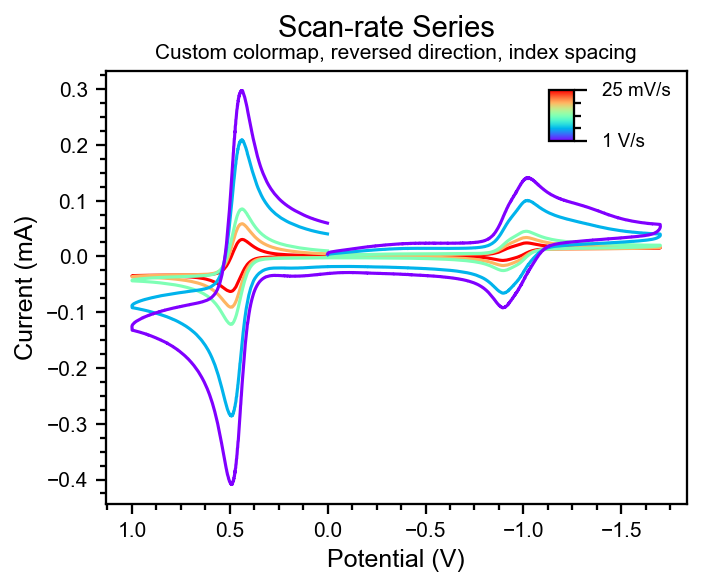

In [9]:
ax = e.multiplot(scan_series, {
    "print": False,
    "title": "Scan-rate Series",
    "subtitle": "Custom colormap, reversed direction, index spacing",
    "gradient by": "scan rate",
    "gradient colormap": "rainbow",
    "gradient reverse": True,
    "gradient scale": "index",
    "legend mode": "colorbar",
    "colorbar tick labels": "endpoints",
    "colorbar trace ticks": True,
    "y unit": "mA",
});

## Compare Groups With `multimultiplot()`

`multimultiplot()` is for grouped comparisons: each group becomes its own coordinated overlay. Build groups with `group()` or `sort_and_group()` first, inspect them with `show_groups()`, then pass the nested list to `multimultiplot()`.

This example groups the full example set by gas. It also introduces `label alterations`, which are display-only text replacements applied while plotting. Here the imported objects keep their full compound metadata, but the legend shortens `3 mM Fc` to `Fc`.



=== 2 Groups Created ===

### Group 0 ###
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: Ar, Compounds: 0.1 M TBAPF₆, Segments: 3, IR Comp Percent: 100 %


,Compounds,Scan Window,Scan Rate
[0][0],,"[-1.2, 1]",100 mV/s
[0][1],"3 mM Fc, 1 mM [Fe]","[-1.2, 1]",100 mV/s
[0][2],"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",100 mV/s
[0][3],"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",25 mV/s
[0][4],"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",500 mV/s
[0][5],"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",1 V/s
[0][6],"3 mM Fc, 1 mM [Fe]","[-1.7, 1]",50 mV/s



### Group 1 ###
[Conditions] Exp Type: CV, Solvent: MeCN, Gas: CO₂, Compounds: 0.1 M TBAPF₆, 3 mM Fc, 1 mM [Fe], Scan Window: [-1.2, 1], Scan Rate: 100 mV/s, Segments: 3, IR Comp Percent: 100 %


,Compounds
[1][0],
[1][1],100 mM PhOH
[1][2],560 mM PhOH
[1][3],1 M PhOH
[1][4],2.8 M PhOH


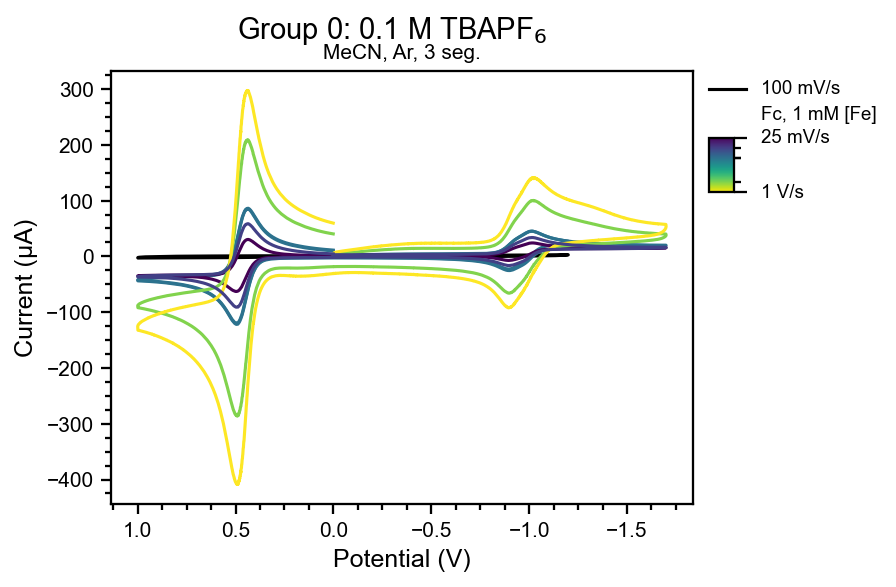

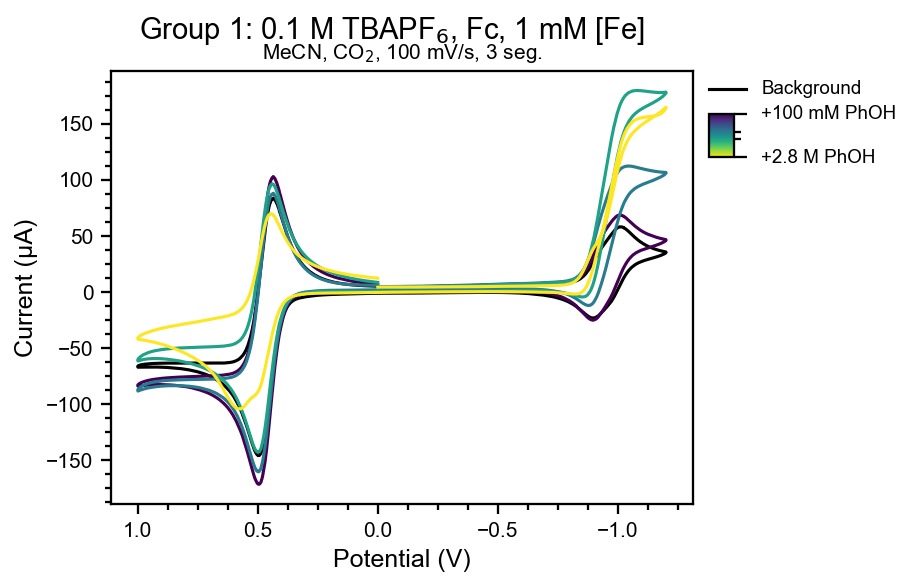

In [10]:
gas_groups = e.sort_and_group(cvs, sort_keys="gas", group_keys="gas")

e.multimultiplot(gas_groups, {
    "print": False,
    "title": "Grouped CV overlays by gas",
    "legend outside": True,
    "label alterations": {"3 mM Fc": "Fc"},
})


## Save A Polished Figure

Save figures from the returned Matplotlib object. Keep generated outputs in `EXPORT_DIR` so the notebook remains portable and easy to clean up.

Saved figure: notebooks/_outputs/plotting_scan_rate_colorbar.png


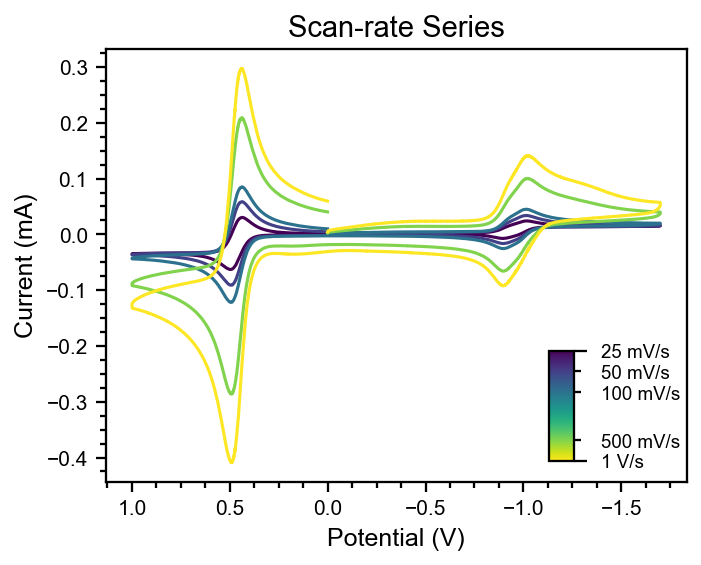

In [11]:
fig_path = EXPORT_DIR / "plotting_scan_rate_colorbar.png"
ax = e.multiplot(scan_series, {
    "print": False,
    "title": "Scan-rate Series",
    "gradient by": "scan rate",
    "legend mode": "colorbar",
    "colorbar tick labels": "all",
    "colorbar height": 2.0,
    "y unit": "mA",
})
ax.figure.savefig(fig_path, dpi=300, bbox_inches="tight")
print("Saved figure:", display_path(fig_path))